In [7]:
import os
import requests
import json
from dotenv import load_dotenv
# from langchain_openai import ChatOpenAI
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_experimental.sql import SQLDatabaseSequentialChain
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.prompts import MessagesPlaceholder, ChatPromptTemplate
from langchain_core.prompts import PromptTemplate
from typing_extensions import Annotated, TypedDict
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain_openai import ChatOpenAI
import psycopg2
import time 
import yaml
import json 
from langchain_community.agent_toolkits import JsonToolkit, create_json_agent
from langchain_community.tools.json.tool import JsonSpec
from langchain_openai import OpenAI
from langchain.tools import Tool

### Add Thingsboard details

In [8]:
THINGSBOARD_URL = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"
DASHBOARD_ID = "http://localhost:8080/tenants"

DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "thingsboard"
DB_USER = "thingsboard"
DB_PASSWORD = "postgres"


THINGSBOARD_HOST = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"

# Authenticate and get the JWT token
auth_url = f'{THINGSBOARD_HOST}/api/auth/login'
auth_payload = {'username': USERNAME, 'password': PASSWORD}
auth_response = requests.post(auth_url, json=auth_payload)
auth_response.raise_for_status()
jwt_token = auth_response.json()['token']

In [9]:
# Load environment variables
load_dotenv()
openai_api_key = os.getenv('OPENAI_PROJECT_API_KEY')

In [10]:
# Load the device metadata
import json 
with open("farm_model_small_v2.json", "r") as file:
    data = json.load(file)

In [11]:
# farm_data['farm']['fields'][0]

In [12]:
def get_farm_details(a: int) -> str:
    """Return Farm field details as a JSON string

    Args:
        a: Field Index
    """
    try:
        field_data = data['farm']['fields'][a]
        return json.dumps(field_data)
    except IndexError:
        return json.dumps({"error": f"Field index {a} is out of bounds."})
    except KeyError:
        return json.dumps({"error": "The 'farm' or 'fields' key was not found in the data."})
    except Exception as e:
        return json.dumps({"error": f"An error occurred: {e}"})

In [13]:
field_index = 0
farm_details_json = get_farm_details(field_index)
print(farm_details_json)

{"F001": {"name": "North Field", "crop": "Maize", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0100"], "field_air_humidity": ["HUM-0100"], "soil_conductivity": ["COND-0100"], "moisture_content": ["MOIST-0100"], "plant_health": ["CAM-0100"]}, "actuator_list": {"pumps": ["PUMP-0100", "PUMP-0101"], "water_valves": ["WV-0100"], "fertilizer_dispensers": ["FD-0100"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0100", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air_humidity": [{"sensor_id": "HUM-0100", "gps": {"lat": 35.6802, "long": -98.1202}, "status": "transmitting", "unit": "grams/cubic meter"}], "soil_conductivity": [{"sensor_id": "COND-0100", "gps": {"lat": 35.6803, "long": -98.1203}, "status": "transmitting", "u

In [14]:
field_index = 6# Assuming there are fewer than 6 fields
farm_details_json = get_farm_details(field_index)
print(farm_details_json)

{"F007": {"name": "West Field", "crop": "Coffee", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0700"], "field_air_humidity": ["HUM-0700"], "soil_conductivity": ["COND-0700"], "moisture_content": ["MOIST-0700"], "plant_health": ["CAM-0700"]}, "actuator_list": {"pumps": ["PUMP-0700", "PUMP-0701"], "water_valves": ["WV-0700"], "fertilizer_dispensers": ["FD-0700"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0700", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air_humidity": [{"sensor_id": "HUM-0700", "gps": {"lat": 35.6802, "long": -98.1202}, "status": "transmitting", "unit": "grams/cubic meter"}], "soil_conductivity": [{"sensor_id": "COND-0700", "gps": {"lat": 35.6803, "long": -98.1203}, "status": "transmitting", "u

In [15]:
# create tool
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_farm_details",
            "description": "Return details about a specific farm field as a JSON object.",
            "parameters": {
                "type": "object",
                "properties": {
                    "a": {
                        "type": "integer",
                        "description": "The index of the field to retrieve details for (0-based).",
                    },
                },
                "required": ["a"],
            },
        },
    }
]

In [16]:
import openai 
# client = openai.OpenAI(api_key=openai_api_key)
client = openai.OpenAI(api_key=openai_api_key)
llm_model = "gpt-3.5-turbo"
# client = ChatOpenAI(api_key=openai_api_key, temperature = 0.0, model=llm_model)
# client = openai.OpenAI(api_key=openai_api_key,model=llm_model)

In [17]:
def run_conversation(query):
    """Runs a conversation with the LLM that can call the get_farm_details tool."""
    messages = [
        {"role": "system", "content": "You are a helpful assistant that identifies relevant devices (sensor_list) mentioned in the user's request and returns them as a JSON array of their IDs e.g. If no specific devices are mentioned, return an empty JSON array."
        "F001 is North Field,"
        "F002 is Northeast Field"
        "F003 is East Field"
        "F004 is Southeast Field"
        "F005 is South Field"
        "F006 is Southwest Field"
        "F007 is West Field"
        "F008 is Northwest Field"
        "F009 is Central Field"
        "Note: if the right Field is not provided return an empty json"
        },
     
        {"role": "user", "content": query}
    ]

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        tools=tools,
        tool_choice="auto", 
    )

    response_message = response.choices[0].message

    if response_message.tool_calls:
        print("LLM initiated a tool call:")
        print(response_message.tool_calls)

        tool_call = response_message.tool_calls[0]
        function_name = tool_call.function.name
        function_to_call = globals()[function_name]
        function_args = json.loads(tool_call.function.arguments)
        function_response = function_to_call(**function_args)

        print(f"Calling function '{function_name}' with arguments: {function_args}")
        print(f"Function returned: {function_response}")

        messages.append(response_message)
        messages.append(
            {
                "tool_call_id": tool_call.id,
                "role": "tool",
                "name": function_name,
                "content": function_response,
            }
        )
        second_response = client.chat.completions.create(
            # model="gpt-3.5-turbo-0613",
            model="gpt-3.5-turbo",
            messages=messages,
        )
        
        return second_response.choices[0].message.content
    else:
        # If no tool call, the LLM might be directly answering based on the system prompt
        try:
            # Attempt to parse the response as JSON (assuming it followed the system prompt)
            return json.loads(response_message.content)
        except (json.JSONDecodeError, TypeError):
            # If it's not valid JSON, return the raw content
            return response_message.content

In [18]:
user_query_farm = "Tell me the details of the sensors in the south  field."
response_farm = run_conversation(user_query_farm)
print(f"\nLLM Response about farm: {response_farm}")


LLM initiated a tool call:
[ChatCompletionMessageToolCall(id='call_6KhY1gmVwtRGswN6wgpGj0Gn', function=Function(arguments='{"a":4}', name='get_farm_details'), type='function')]
Calling function 'get_farm_details' with arguments: {'a': 4}
Function returned: {"F005": {"name": "South Field", "crop": "soybean", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0500"], "field_air_humidity": ["HUM-0500"], "soil_conductivity": ["COND-0500"], "moisture_content": ["MOIST-0500"], "plant_health": ["CAM-0500"]}, "actuator_list": {"pumps": ["PUMP-0500", "PUMP-0501"], "water_valves": ["WV-0500"], "fertilizer_dispensers": ["FD-0500"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0500", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air

In [19]:
user_query_farm = "Tell me the details of the sensors in the east  field."
response_farm = run_conversation(user_query_farm)
print(f"\nLLM Response about farm: {response_farm}")


LLM initiated a tool call:
[ChatCompletionMessageToolCall(id='call_HDdi7uYJjH38Rm28kV4QsDGd', function=Function(arguments='{"a":2}', name='get_farm_details'), type='function')]
Calling function 'get_farm_details' with arguments: {'a': 2}
Function returned: {"F003": {"name": "East Field", "crop": "Sorghum", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0300"], "field_air_humidity": ["HUM-0300"], "soil_conductivity": ["COND-0300"], "moisture_content": ["MOIST-0300"], "plant_health": ["CAM-0300"]}, "actuator_list": {"pumps": ["PUMP-0300", "PUMP-0301"], "water_valves": ["WV-0300"], "fertilizer_dispensers": ["FD-0300"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0300", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air_

In [20]:
user_query_farm = "Tell me the details of the sensors in the give South field."
response_farm = run_conversation(user_query_farm)
print(f"\nLLM Response about farm: {response_farm}")


LLM initiated a tool call:
[ChatCompletionMessageToolCall(id='call_aKROKCtBalHiFlfvxDTSRGZJ', function=Function(arguments='{"a":4}', name='get_farm_details'), type='function')]
Calling function 'get_farm_details' with arguments: {'a': 4}
Function returned: {"F005": {"name": "South Field", "crop": "soybean", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0500"], "field_air_humidity": ["HUM-0500"], "soil_conductivity": ["COND-0500"], "moisture_content": ["MOIST-0500"], "plant_health": ["CAM-0500"]}, "actuator_list": {"pumps": ["PUMP-0500", "PUMP-0501"], "water_valves": ["WV-0500"], "fertilizer_dispensers": ["FD-0500"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0500", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air

In [21]:
user_query_farm = "Tell me the details of the temperature sensor in the give South field."
response_farm = run_conversation(user_query_farm)
print(f"\nLLM Response about farm: {response_farm}")


LLM initiated a tool call:
[ChatCompletionMessageToolCall(id='call_3JEca6AGSyGT7cRVl0itmIrV', function=Function(arguments='{"a":4}', name='get_farm_details'), type='function')]
Calling function 'get_farm_details' with arguments: {'a': 4}
Function returned: {"F005": {"name": "South Field", "crop": "soybean", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0500"], "field_air_humidity": ["HUM-0500"], "soil_conductivity": ["COND-0500"], "moisture_content": ["MOIST-0500"], "plant_health": ["CAM-0500"]}, "actuator_list": {"pumps": ["PUMP-0500", "PUMP-0501"], "water_valves": ["WV-0500"], "fertilizer_dispensers": ["FD-0500"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0500", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air

In [22]:
user_query_farm = "Tell me the details of the temperature sensor in the give East field."
response_farm = run_conversation(user_query_farm)
print(f"\nLLM Response about farm: {response_farm}")


LLM initiated a tool call:
[ChatCompletionMessageToolCall(id='call_O0SPzAgm03jGRofji3QjYQhU', function=Function(arguments='{"a":2}', name='get_farm_details'), type='function')]
Calling function 'get_farm_details' with arguments: {'a': 2}
Function returned: {"F003": {"name": "East Field", "crop": "Sorghum", "area": "62.5 acres", "boundary_gps": {"north": {"lat": 35.6789, "long": -98.1234}, "east": {"lat": 35.6789, "long": -98.1234}, "south": {"lat": 35.6789, "long": -98.1234}, "west": {"lat": 35.6789, "long": -98.1234}}, "sensor_list": {"soil_temperature": ["TEMP-0300"], "field_air_humidity": ["HUM-0300"], "soil_conductivity": ["COND-0300"], "moisture_content": ["MOIST-0300"], "plant_health": ["CAM-0300"]}, "actuator_list": {"pumps": ["PUMP-0300", "PUMP-0301"], "water_valves": ["WV-0300"], "fertilizer_dispensers": ["FD-0300"]}, "sensors": {"soil_temperature": [{"sensor_id": "TEMP-0300", "gps": {"lat": 35.6801, "long": -98.1201}, "status": "transmitting", "unit": "celsius"}], "field_air_

In [23]:
sensor_ids = json.loads(response_farm)["sensor_list"]
sensor_ids

['TEMP-0300']

In [24]:
# 2. Get device ID by name
def get_device_id_by_name(device_name, token):
    headers = {
        "Content-Type": "application/json",
        "X-Authorization": f"Bearer {token}"
    }
    url = f"{THINGSBOARD_URL}/api/tenant/devices?deviceName={device_name}"
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    device = response.json()
    return device['id']['id'] if device else None

In [25]:
def get_device_keys(jwt_token, device_id):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/keys/timeseries"
    headers = {
        "X-Authorization": f"Bearer {jwt_token}"
    }

    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()  # Returns a list of key names
    else:
        return {
            "error": f"Failed to fetch keys: {response.status_code}",
            "details": response.text
        }

In [26]:
# change the device name 
device_name = sensor_ids[0] #"HUM-0100"
sensor_id = get_device_id_by_name(device_name, jwt_token)
device_id = sensor_id
sensor_id

'e8278450-1221-11f0-a236-5f0808fc8cdf'

In [27]:
device_key = get_device_keys(jwt_token, sensor_id)
device_key = device_key[-1] # ['deviceId', 'unit', 'relative_humidity']
device_key 

'temp'

# Get data for the last 24 hours

In [28]:
# Last 24 hours timestamps
end_ts = int(time.time() * 1000)  
start_ts = end_ts - (340 * 60 * 60 * 1000)  # 24 hours ago

# keys = "temperature"  
keys = device_key


def get_historical_data(jwt_token, device_id, start_ts, end_ts, keys):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/values/timeseries"
    params = {"keys": keys, "startTs": start_ts, "endTs": end_ts, "limit": 100}
    headers = {"X-Authorization": f"Bearer {jwt_token}"}
    
    response = requests.get(url, headers=headers, params=params)
    return response.json() if response.status_code == 200 else {"error": "Failed to fetch telemetry data"}

response = get_historical_data(jwt_token, device_id, start_ts, end_ts, keys)
response

{'temp': [{'ts': 1743869010432, 'value': '31.933204571888812'},
  {'ts': 1743868708445, 'value': '33.19160142917518'},
  {'ts': 1743868406011, 'value': '31.889659300228587'},
  {'ts': 1743868104046, 'value': '27.630087114836975'},
  {'ts': 1743867801985, 'value': '32.59882128269354'},
  {'ts': 1743867499608, 'value': '30.084740635853226'},
  {'ts': 1743867197569, 'value': '32.77083049788599'},
  {'ts': 1743866895475, 'value': '29.67118776990474'},
  {'ts': 1743866593137, 'value': '33.74789752191496'},
  {'ts': 1743866291289, 'value': '32.514507810535704'},
  {'ts': 1743865988999, 'value': '32.98042091321137'},
  {'ts': 1743864782071, 'value': '30.429855299683076'}]}

In [29]:
telemetry_data = response

## Visualization of real-time data

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


# # Convert telemetry data into a DataFrame
data = []
for key, values in telemetry_data.items():
    for entry in values:
        data.append({
            'timestamp': datetime.utcfromtimestamp(entry['ts'] / 1000),
            'metric': key,
            'value': float(entry['value'])
        })

df = pd.DataFrame(data)


/Users/george/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/bw/zwn916250j389j86x0z9f6tr0000gn/T/matplotlib-qezf4u07 because there was an issue with the default path (/Users/george/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


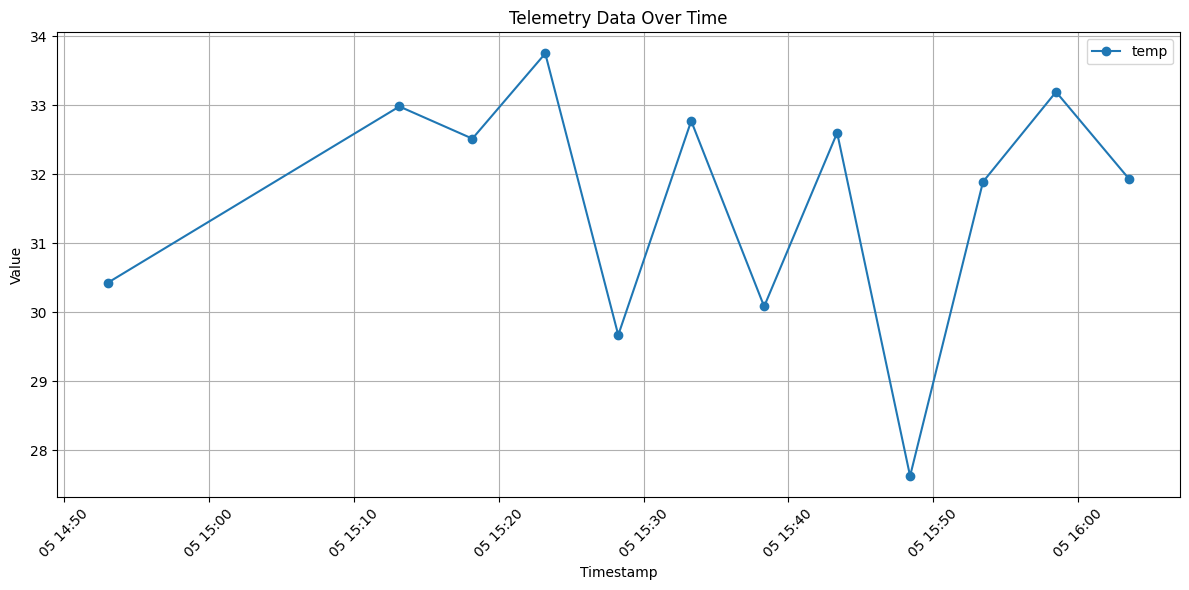

In [31]:
# Pivot the DataFrame for easier plotting
pivot_df = df.pivot(index='timestamp', columns='metric', values='value')

# Plotting
plt.figure(figsize=(12, 6))
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker='o', label=column)

plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Telemetry Data Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
def realtime_telemetry_data(): 
    """Fetch realtime telemetry data from the sensor."""
    return fetch_telemetry_data(REALTIME_TELEMETRY_URL)

In [ ]:
real_time_agent = create_react_agent(
    model = model,
    tools = [realtime_telemetry_data], 
    name = "real_time_agent", 
    prompt="You are a realtime agent, you give realtime sensor data")

In [ ]:
workflow = create_supervisor(
    [real_time_agent,],
    model=model, 
    prompt=("You are a sensor data supervisor managing realtime and database data"
           "For current data use realtime_agent"
           "For hostorical data use database_agent"
           "For general knowledge information about the farm use the rag_agent")
)

app = workflow.compile()

In [ ]:
from IPython.display import Image

display(Image(app.get_graph().draw_mermaid_png()))